**Importing the Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

**Download NLTK resources**

In [2]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MTB\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MTB\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\MTB\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\MTB\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

**Loading the dataset**

In [3]:
df = pd.read_csv("../dataset/amazon_alexa.tsv", sep="\t")
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


### Data Exploration Section

**Displaying first 5 rows**

In [4]:
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


**Displaying Last 5 rows**

In [5]:
df.tail()

,rating,date,variation,verified_reviews,feedback
3145,5,30-Jul-18,Black Dot,"Perfect for kids, adults and everyone in betwe...",1
3146,5,30-Jul-18,Black Dot,"Listening to music, searching locations, check...",1
3147,5,30-Jul-18,Black Dot,"I do love these things, i have them running my...",1
3148,5,30-Jul-18,White Dot,Only complaint I have is that the sound qualit...,1
3149,4,29-Jul-18,Black Dot,Good,1


**Dataset Shape**

In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (3150, 5)


**Displaying Column Names**

In [7]:
print(df.columns)

Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback'], dtype='object')


**Displaying Dataset Information**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


Displaying Statistical Summary of the Dataset

In [9]:
df.describe()

,rating,feedback
count,3150.000000,3150.000000
mean,4.463175,0.918413
std,1.068506,0.273778
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


Displaying Statistical Summary Including Text Columns

In [10]:
df.describe(include='all')

,rating,date,variation,verified_reviews,feedback
count,3150.000000,3150,3150,3149,3150.000000
unique,NaN,77,16,2300,NaN
top,NaN,30-Jul-18,Black Dot,,NaN
freq,NaN,1603,516,79,NaN
mean,4.463175,NaN,NaN,NaN,0.918413
std,1.068506,NaN,NaN,NaN,0.273778
min,1.000000,NaN,NaN,NaN,0.000000
25%,4.000000,NaN,NaN,NaN,1.000000
50%,5.000000,NaN,NaN,NaN,1.000000
75%,5.000000,NaN,NaN,NaN,1.000000


Displaying Missing Values

In [11]:
print(df.isnull().sum())

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


Displaying Duplicate Records

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 715


Displaying Unique Values

In [13]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].nunique())


rating
5

date
77

variation
16

verified_reviews
2300

feedback
2


Displaying Random Reviews

In [14]:
df.sample(5)

,rating,date,variation,verified_reviews,feedback
1229,3,26-Jul-18,Black Spot,It was much smaller than I was expecting for t...,1
1748,5,28-Jul-18,Black Show,Love seeing everything in the display!,1
1906,1,26-Jul-18,White Plus,"It does not speak in Spanish,,,I bought it for...",0
2154,5,30-Jul-18,Configuration: Fire TV Stick,The firestick is easy to use and was super eas...,1
1752,5,30-Jul-18,White Plus,Great speaker i n this! I love this so much mo...,1


### Observations

- The dataset contains approximately 3,150 reviews.
- There are 5 columns.
- The target variable is `feedback`.
- Most columns contain no missing values.
- Duplicate reviews may be present and will be handled during preprocessing.
- The review text is stored in the `verified_reviews` column.

### Data Cleaning Section

**Checking Missing Values**

In [15]:
df.isnull().sum()
df = df.dropna(subset=["verified_reviews"])

**Checking Duplicate Rows**

In [16]:
print("Duplicate rows before cleaning:", df.duplicated().sum())

Duplicate rows before cleaning: 715


**Remove Duplicate Rows**

In [17]:
df = df.drop_duplicates()

**Verify Duplicates Were Removed**

In [18]:
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


**Keeping only Requried Columns**

In [19]:
df = df[["verified_reviews", "feedback"]]

**Rename Columns**

In [20]:
df = df.rename(columns={
    "verified_reviews": "review",
    "feedback": "sentiment"
})

**Display the Updated Dataset**

In [21]:
df.head()

,review,sentiment
0,Love my Echo!,1
1,Loved it!,1
2,"Sometimes while playing a game, you can answer...",1
3,I have had a lot of fun with this thing. My 4 ...,1
4,Music,1


**Checking the Shape of the Dataset again**

In [22]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2434, 2)


**Verify Data Types**

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2434 entries, 0 to 2800
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     2434 non-null   object
 1   sentiment  2434 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 57.0+ KB


### Observations

- Missing values were checked and handled.
- Duplicate records were removed.
- Only the review text and sentiment label were retained.
- The dataset is now ready for text preprocessing.

## Basic Text Preprocessing

**Importing Required Libraries**

In [24]:
import re
import string

**Create a Cleaning Function**

In [25]:
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

**Applying the Function**

In [26]:
df["clean_review"] = df["review"].apply(clean_text)

**Comparing Before and After**

In [27]:
df[["review", "clean_review"]].head(10)

,review,clean_review
0,Love my Echo!,love my echo
1,Loved it!,loved it
2,"Sometimes while playing a game, you can answer...",sometimes while playing a game you can answer ...
3,I have had a lot of fun with this thing. My 4 ...,i have had a lot of fun with this thing my yr ...
4,Music,music
5,I received the echo as a gift. I needed anothe...,i received the echo as a gift i needed another...
6,"Without having a cellphone, I cannot use many ...",without having a cellphone i cannot use many o...
7,I think this is the 5th one I've purchased. I'...,i think this is the th one ive purchased im wo...
8,looks great,looks great
9,Love it! I’ve listened to songs I haven’t hear...,love it i’ve listened to songs i haven’t heard...


**Check for Missing Values**

In [28]:
df["clean_review"].isnull().sum()

np.int64(0)

**Displaying Random Examples**

In [29]:
df[["review", "clean_review"]].sample(5, random_state=42)

,review,clean_review
438,Love,love
2481,Love my echo. Love playing music in my room,love my echo love playing music in my room
612,Worked as advertised. Thanks,worked as advertised thanks
1452,I'm loving my new Echo Show. The video screen ...,im loving my new echo show the video screen ad...
2471,I AM COMPLETELY IN LOVE. DOES ABSOLUTELY EVERY...,i am completely in love does absolutely everyt...


### Observations

- All reviews were converted to lowercase.
- Punctuation marks were removed.
- Numerical values were removed.
- Extra spaces were eliminated.
- A new column (`clean_review`) was created while preserving the original review text.

### Tokenization and Stopword Removal

**Importing Required Libraries**

In [30]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

**Loading English Stopwords**

In [31]:
stop_words = set(stopwords.words('english'))

**Creating the Function**

In [32]:
def remove_stopwords(text):
    words = word_tokenize(text)

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

**Applying the Function**

In [33]:
df["processed_review"] = df["clean_review"].apply(remove_stopwords)

**Comparing the Results**

In [34]:
df[["review",
    "clean_review",
    "processed_review"]].head(10)

,review,clean_review,processed_review
0,Love my Echo!,love my echo,love echo
1,Loved it!,loved it,loved
2,"Sometimes while playing a game, you can answer...",sometimes while playing a game you can answer ...,sometimes playing game answer question correct...
3,I have had a lot of fun with this thing. My 4 ...,i have had a lot of fun with this thing my yr ...,lot fun thing yr old learns dinosaurs control ...
4,Music,music,music
5,I received the echo as a gift. I needed anothe...,i received the echo as a gift i needed another...,received echo gift needed another bluetooth so...
6,"Without having a cellphone, I cannot use many ...",without having a cellphone i cannot use many o...,without cellphone use many features ipad see u...
7,I think this is the 5th one I've purchased. I'...,i think this is the th one ive purchased im wo...,think th one ive purchased im working getting ...
8,looks great,looks great,looks great
9,Love it! I’ve listened to songs I haven’t hear...,love it i’ve listened to songs i haven’t heard...,love ’ listened songs ’ heard since childhood ...


**Viewing Random Examples**

In [35]:
df[["review",
    "processed_review"]].sample(10, random_state=42)

,review,processed_review
438,Love,love
2481,Love my echo. Love playing music in my room,love echo love playing music room
612,Worked as advertised. Thanks,worked advertised thanks
1452,I'm loving my new Echo Show. The video screen ...,im loving new echo show video screen adds much...
2471,I AM COMPLETELY IN LOVE. DOES ABSOLUTELY EVERY...,completely love absolutely everything amazing ...
2328,I don't like how I cannot load my Hulu account...,dont like load hulu account also slow know int...
1814,I decided to buy smart door lock and decided o...,decided buy smart door lock decided getting ec...
1417,I LOVE THIS ITEM... I UNDERESTIMATED THIS ITEM...,love item underestimated item another cart im ...
251,Simply love my Echo. I hardly watch any TV at ...,simply love echo hardly watch tv anymore im bu...
2682,I had an Alexia built into my thermostat that ...,alexia built thermostat didnt work well standi...


**Count Words Before and After**

In [36]:
# Before
print("Words before preprocessing:")

print(df["clean_review"]
      .str.split()
      .str.len()
      .mean())

Words before preprocessing:
26.175842235004108


In [37]:
# After
print("Words after stopword removal:")

print(df["processed_review"]
      .str.split()
      .str.len()
      .mean())

Words after stopword removal:
13.341824157764997


### Observations

- Reviews were tokenized into individual words.
- Common English stopwords were removed.
- A new column (`processed_review`) was created.
- The average number of words per review decreased after stopword removal.

## Lemmatization

**Import the Lemmatizer**

In [38]:
from nltk.stem import WordNetLemmatizer

**Creating the Lemmatizer Object**

In [39]:
lemmatizer = WordNetLemmatizer()

**Creating a Function**

In [40]:
def lemmatize_text(text):
    words = word_tokenize(text)

    lemmatized_words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(lemmatized_words)

**Applying the Function**

In [41]:
df["lemmatized_review"] = df["processed_review"].apply(lemmatize_text)

**Comparing the Results**

In [42]:
df[
    [
        "review",
        "processed_review",
        "lemmatized_review"
    ]
].head(10)

,review,processed_review,lemmatized_review
0,Love my Echo!,love echo,love echo
1,Loved it!,loved,loved
2,"Sometimes while playing a game, you can answer...",sometimes playing game answer question correct...,sometimes playing game answer question correct...
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing yr old learns dinosaurs control ...,lot fun thing yr old learns dinosaur control l...
4,Music,music,music
5,I received the echo as a gift. I needed anothe...,received echo gift needed another bluetooth so...,received echo gift needed another bluetooth so...
6,"Without having a cellphone, I cannot use many ...",without cellphone use many features ipad see u...,without cellphone use many feature ipad see us...
7,I think this is the 5th one I've purchased. I'...,think th one ive purchased im working getting ...,think th one ive purchased im working getting ...
8,looks great,looks great,look great
9,Love it! I’ve listened to songs I haven’t hear...,love ’ listened songs ’ heard since childhood ...,love ’ listened song ’ heard since childhood g...


**Show Random Examples**

In [43]:
df[
    [
        "processed_review",
        "lemmatized_review"
    ]
].sample(10, random_state=42)

,processed_review,lemmatized_review
438,love,love
2481,love echo love playing music room,love echo love playing music room
612,worked advertised thanks,worked advertised thanks
1452,im loving new echo show video screen adds much...,im loving new echo show video screen add much ...
2471,completely love absolutely everything amazing ...,completely love absolutely everything amazing ...
2328,dont like load hulu account also slow know int...,dont like load hulu account also slow know int...
1814,decided buy smart door lock decided getting ec...,decided buy smart door lock decided getting ec...
1417,love item underestimated item another cart im ...,love item underestimated item another cart im ...
251,simply love echo hardly watch tv anymore im bu...,simply love echo hardly watch tv anymore im bu...
2682,alexia built thermostat didnt work well standi...,alexia built thermostat didnt work well standi...


**Check for Missing Values**

In [44]:
df["lemmatized_review"].isnull().sum()

np.int64(0)

### Observations

- Words were converted to their base form using WordNet Lemmatizer.
- A new column (`lemmatized_review`) was created.
- Lemmatization helps reduce vocabulary size while preserving the meaning of words.

### Exploratory Data Analysis (EDA)

**Count Positive and Negative Reviews**

In [45]:
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
1    2214
0     220
Name: count, dtype: int64


**Displaying Percentages**

In [46]:
sentiment_percentage = (
    df["sentiment"]
    .value_counts(normalize=True)
    * 100
)

print(sentiment_percentage)

sentiment
1    90.96138
0     9.03862
Name: proportion, dtype: float64


**Creating a Bar Chart**

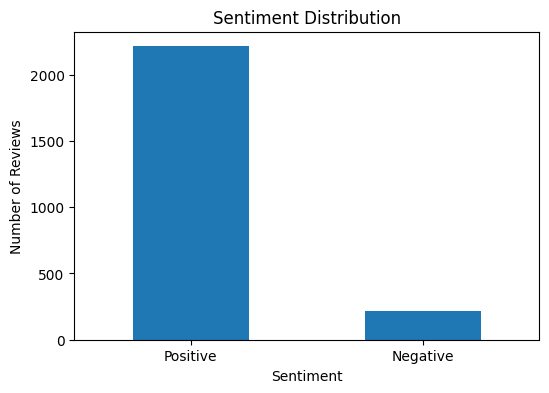

In [47]:
plt.figure(figsize=(6,4))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.xticks([0,1],["Positive","Negative"], rotation=0)

plt.show()

**Saving the Figure**

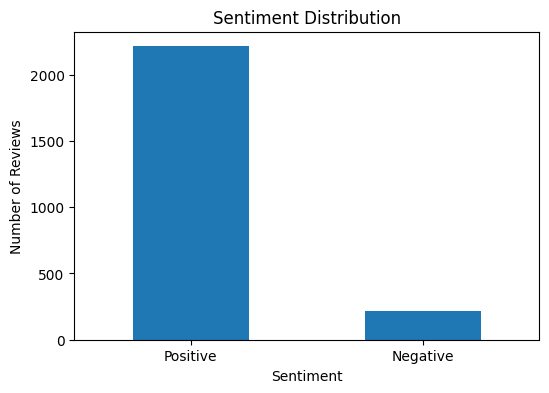

In [48]:
plt.figure(figsize=(6,4))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.xticks([0,1],["Positive","Negative"], rotation=0)

plt.savefig("../outputs/sentiment_distribution.png")

plt.show()

### Observations

- The dataset contains both positive and negative reviews.
- Positive reviews are significantly more frequent than negative reviews.
- The dataset is imbalanced, which should be considered during model evaluation.

## Review Length Analysis

**Creating a Review Length Column**

In [49]:
df["review_length"] = df["lemmatized_review"].apply(lambda x: len(x.split()))

**Viewing the Data**

In [50]:
df[["lemmatized_review", "review_length"]].head()

,lemmatized_review,review_length
0,love echo,2
1,loved,1
2,sometimes playing game answer question correct...,17
3,lot fun thing yr old learns dinosaur control l...,18
4,music,1


**Basic Statistics**

In [51]:
df["review_length"].describe()

count    2434.000000
mean       13.341824
std        17.846512
min         0.000000
25%         3.000000
50%         8.000000
75%        16.000000
max       257.000000
Name: review_length, dtype: float64

**Average Review Length by Sentiment**

In [52]:
average_length = df.groupby("sentiment")["review_length"].mean()

print(average_length)

sentiment
0    20.936364
1    12.587173
Name: review_length, dtype: float64


**Visualize Average Review Length**

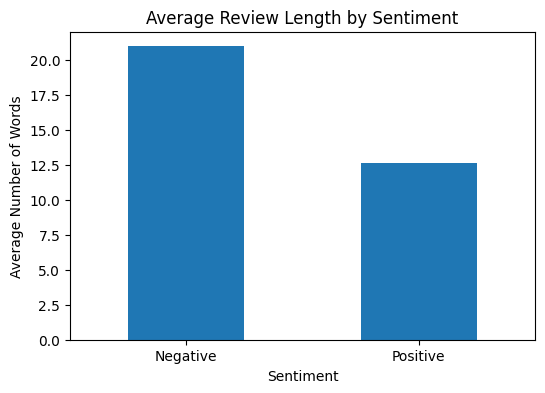

In [53]:
plt.figure(figsize=(6,4))

average_length.plot(kind="bar")

plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Number of Words")

plt.xticks([0,1],["Negative","Positive"], rotation=0)

plt.show()

**Histogram of Review Length**

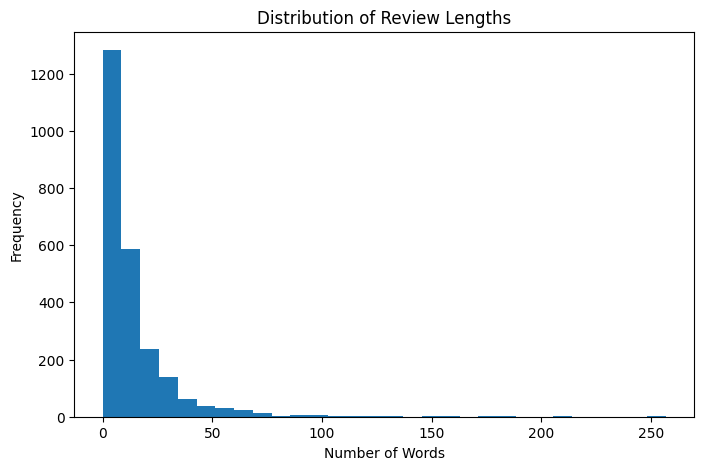

In [54]:
plt.figure(figsize=(8,5))

plt.hist(df["review_length"], bins=30)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

**Save Both Figures**

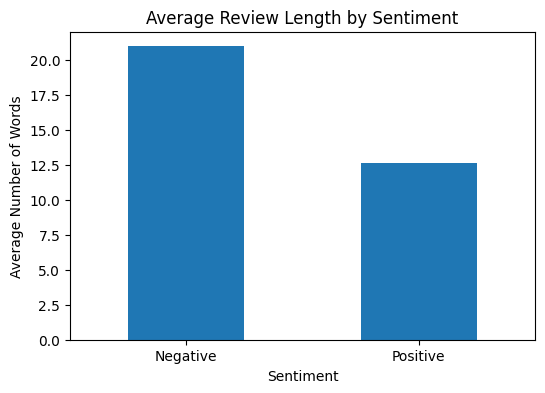

In [55]:
plt.figure(figsize=(6,4))

average_length.plot(kind="bar")

plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Number of Words")

plt.xticks([0,1],["Negative","Positive"], rotation=0)

plt.savefig("../outputs/review_length_by_sentiment.png")

plt.show()

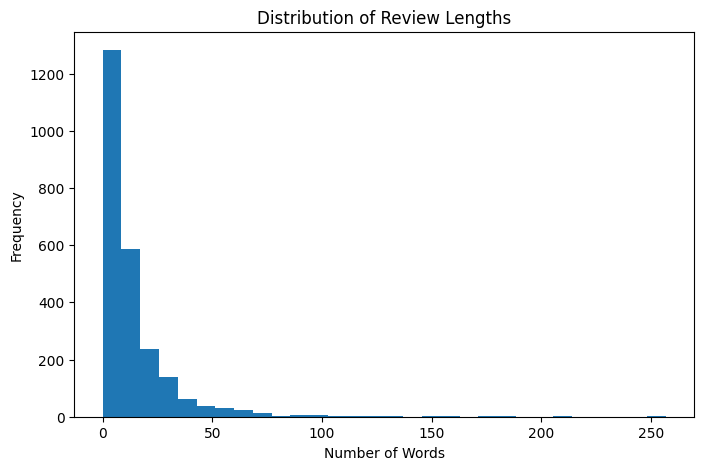

In [56]:
# Histogram
plt.figure(figsize=(8,5))

plt.hist(df["review_length"], bins=30)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.savefig("../outputs/review_length_distribution.png")

plt.show()

### Observations

- Review lengths vary across the dataset.
- The average review length differs between positive and negative reviews.
- Most reviews contain a relatively small number of words.
- Review length alone is not sufficient to determine sentiment but provides useful insight into customer feedback patterns.

## Feature Engineering - Bag of Words

**Import CountVectorizer**

In [57]:
from sklearn.feature_extraction.text import CountVectorizer

**Create the Vectorizer**

In [58]:
bow_vectorizer = CountVectorizer()

**Convert Text into Vectors**

In [59]:
bow_features = bow_vectorizer.fit_transform(df["lemmatized_review"])

**Checking the Shape**

In [60]:
print("Bag of Words Matrix Shape:")
print(bow_features.shape)

Bag of Words Matrix Shape:
(2434, 3823)


**Display Vocabulary Size**

In [61]:
print("Vocabulary Size:", len(bow_vectorizer.vocabulary_))

Vocabulary Size: 3823


**Display Some Vocabulary Words**

In [62]:
feature_names = bow_vectorizer.get_feature_names_out()

print(feature_names[:30])

['abay' 'abc' 'abd' 'ability' 'able' 'abode' 'absolutely' 'absolutly' 'ac'
 'accent' 'accentthe' 'acceptable' 'accepting' 'access' 'accessable'
 'accessible' 'accessing' 'accessneeds' 'accessory' 'accessto' 'accident'
 'accidentally' 'accompanying' 'accomplish' 'accomplished' 'according'
 'accordingly' 'account' 'accuracy' 'accurate']


**Convert a Small Sample into a Table**

In [63]:
import pandas as pd

sample_bow = pd.DataFrame(
    bow_features[:5].toarray(),
    columns=feature_names
)

sample_bow.head()

,abay,abc,abd,ability,able,abode,absolutely,absolutly,ac,accent,...,youtubes,yr,yup,zero,zigbee,zonkedout,zwave,zzzz,zzzzzzz,útil
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## How Bag of Words Works

Example Reviews:

Review 1:
```
I love Alexa
```

Review 2:
```
Alexa plays music
```

Vocabulary:

```
love
alexa
plays
music
```

Vector Representation:

| Review | love | alexa | plays | music |
|--------|-----:|------:|------:|------:|
| I love Alexa | 1 | 1 | 0 | 0 |
| Alexa plays music | 0 | 1 | 1 | 1 |

### Observations

- The Bag of Words model converts text into numerical vectors.
- Each column represents a unique word in the vocabulary.
- Each row represents one customer review.
- The values indicate how many times each word appears in a review.

## Feature Engineering - TF-IDF

**Import TF-IDF**

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

**Create TF-IDF Vectorizer**

In [65]:
tfidf_vectorizer = TfidfVectorizer()

**Transform Reviews**

In [66]:
tfidf_features = tfidf_vectorizer.fit_transform(df["lemmatized_review"])

**Check Shape**

In [67]:
print("TF-IDF Matrix Shape:")
print(tfidf_features.shape)

TF-IDF Matrix Shape:
(2434, 3823)


**Vocabulary Size**

In [68]:
print("Vocabulary Size:", len(tfidf_vectorizer.vocabulary_))

Vocabulary Size: 3823


**Display Sample Features**

In [69]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print(feature_names[:30])

['abay' 'abc' 'abd' 'ability' 'able' 'abode' 'absolutely' 'absolutly' 'ac'
 'accent' 'accentthe' 'acceptable' 'accepting' 'access' 'accessable'
 'accessible' 'accessing' 'accessneeds' 'accessory' 'accessto' 'accident'
 'accidentally' 'accompanying' 'accomplish' 'accomplished' 'according'
 'accordingly' 'account' 'accuracy' 'accurate']


**Display TF-IDF Values**

In [70]:
tfidf_df = pd.DataFrame(
    tfidf_features[:5].toarray(),
    columns=feature_names
)

tfidf_df.head()

,abay,abc,abd,ability,able,abode,absolutely,absolutly,ac,accent,...,youtubes,yr,yup,zero,zigbee,zonkedout,zwave,zzzz,zzzzzzz,útil
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.206212,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.335455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Bag of Words vs TF-IDF

| Bag of Words | TF-IDF |
|---------------|---------|
| Counts word frequency | Assigns importance scores |
| Common words have high counts | Common words receive lower weights |
| Simpler representation | More informative representation |
| Does not consider word importance | Considers how unique a word is across documents |

TF-IDF generally produces better features for text classification tasks such as sentiment analysis.

### Observations

- TF-IDF converts text into numerical vectors.
- The feature matrix has the same dimensions as Bag of Words.
- TF-IDF assigns weights instead of simple word counts.
- Common words receive lower importance while informative words receive higher importance.

## Train-Test Split

**Select Features and Target**

In [71]:
X = tfidf_features
y = df["sentiment"]

**Split the Dataset**

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

**Check the Shapes**

In [73]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (1947, 3823)
Testing Features : (487, 3823)
Training Labels  : (1947,)
Testing Labels   : (487,)


**Verify Class Distribution**

In [74]:
print("Training Set Distribution")
print(y_train.value_counts())

print("\nTesting Set Distribution")
print(y_test.value_counts())

Training Set Distribution
sentiment
1    1771
0     176
Name: count, dtype: int64

Testing Set Distribution
sentiment
1    443
0     44
Name: count, dtype: int64


### Observations

- The dataset was divided into training and testing sets.
- 80% of the data will be used for training.
- 20% of the data will be used for testing.
- Stratified sampling was used to preserve the sentiment distribution in both datasets.

## Logistic Regression Model Training

**Import Logistic Regression**

In [75]:
from sklearn.linear_model import LogisticRegression

**Create the Model**

In [76]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

**Train the Model**

In [77]:
logistic_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

**Make Predictions**

In [78]:
y_pred_logistic = logistic_model.predict(X_test)

**Display Sample Predictions**

In [79]:
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_logistic
})

prediction_df.head(10)

,Actual,Predicted
0,1,1
1,0,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


**Predict a Single Review**

In [80]:
sample_review = [
    "This product is absolutely amazing and easy to use."
]

sample_vector = tfidf_vectorizer.transform(sample_review)

prediction = logistic_model.predict(sample_vector)

print(prediction)

[1]


### Observations

- Logistic Regression was successfully trained on the TF-IDF feature vectors.
- The trained model was able to generate predictions for unseen reviews.
- Initial predictions indicate that the model has learned useful patterns from the training data.